<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/Decesion_tree_classiifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Step 1: Import core packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [14]:
from google.colab import files

upload = files.upload()


Saving Hospital_Readmission_Prediction.csv to Hospital_Readmission_Prediction (1).csv


In [15]:
df = pd.read_csv("Hospital_Readmission_Prediction.csv")
print(df)

      Patient_Age  Hospital_Stay_Days  Previous_Admissions  \
0              69                  18                    6   
1              32                   5                    2   
2              89                  13                    2   
3              78                   4                    6   
4              38                  17                    3   
...           ...                 ...                  ...   
1995           56                  14                    1   
1996           22                  18                    7   
1997           82                  18                    4   
1998           30                  16                    0   
1999           70                   1                    0   

      Chronic_Conditions  Followup_Visits_Missed Readmission  
0                      0                       2          No  
1                      5                       9         Yes  
2                      2                       8         Yes  
3  

In [16]:
# Step 3: Preprocessing Categorical Data
le = LabelEncoder()

# Example: Converting a text target column to numeric markers
if df['Readmission'].dtype == 'object':
    df['Readmission'] = le.fit_transform(df['Readmission'])

In [17]:
# Step 4: Split features and target
X = df.drop(columns=['Readmission'])
y = df['Readmission']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Step 5: Initialize and fit the Decision Tree model
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [19]:
# Step 6: Model evaluation
y_pred = model.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Decision Tree Accuracy: 85.50%

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.92      0.85       184
           1       0.92      0.80      0.86       216

    accuracy                           0.85       400
   macro avg       0.86      0.86      0.85       400
weighted avg       0.86      0.85      0.86       400



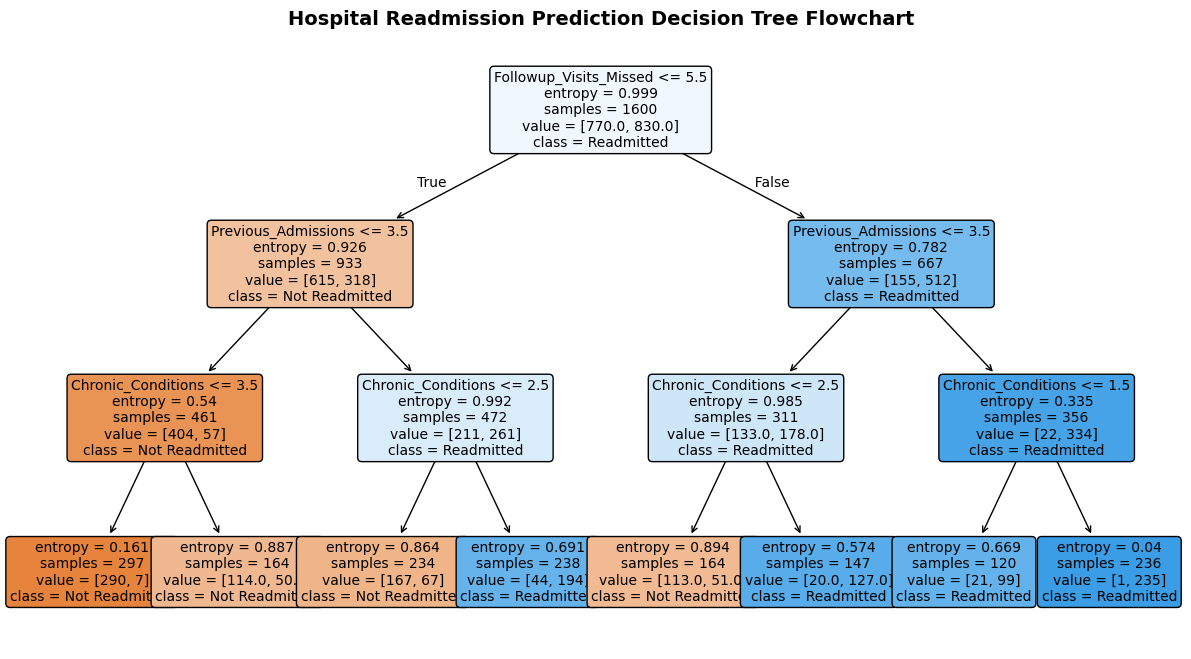

In [23]:
# Step 7: Visualize the trained Decision Tree flowchart
plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Readmitted', 'Readmitted'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Hospital Readmission Prediction Decision Tree Flowchart", fontsize=14, fontweight='bold')
plt.show()